In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn import metrics
from sklearn.metrics import mean_squared_error

In [3]:
boston = pd.read_csv('/Users/Fanny/Desktop/CS0075_codes_data/Boston.csv')
boston.dropna(inplace = True)    

#dropna(): This method scans the DataFrame for any rows with missing (NaN) values and removes them.
#inplace=True: This tells pandas to modify the original DataFrame directly rather than returning a new one.

In [4]:
df = pd.DataFrame(boston) 

In [5]:
df.shape

(506, 15)

In [6]:
df.columns

Index(['Unnamed: 0', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis',
       'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv'],
      dtype='object')

In [7]:
df.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [8]:
# Check for missing values
df.isnull().sum()

Unnamed: 0    0
crim          0
zn            0
indus         0
chas          0
nox           0
rm            0
age           0
dis           0
rad           0
tax           0
ptratio       0
black         0
lstat         0
medv          0
dtype: int64

In [10]:
# See rows with missing values
df[df.isnull().any(axis=1)]

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv


In [11]:
# Finding out the correlation between the features
corr = df.corr()
corr

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
Unnamed: 0,1.000000,0.407407,-0.103393,0.399439,-0.003759,0.398736,-0.079971,0.203784,-0.302211,0.686002,0.666626,0.291074,-0.295041,0.258465,-0.226604
crim,0.407407,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.103393,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.399439,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.003759,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.398736,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.079971,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.203784,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.302211,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.686002,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626


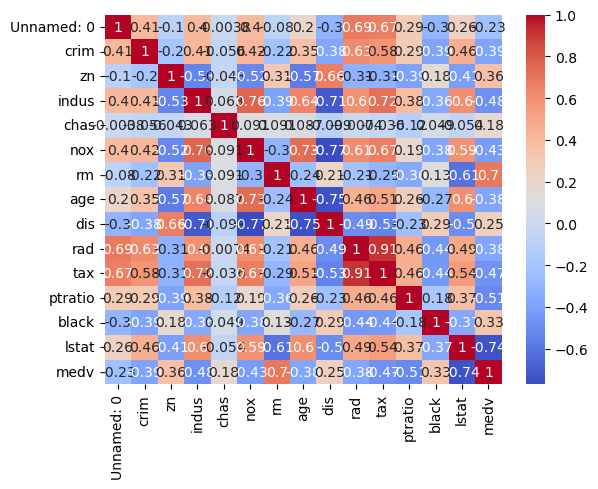

In [21]:
sns.heatmap(corr, annot=True, cmap='coolwarm')    #cmap values: coolwarm,RdBu,BrBG,PiYG,Spectral,seismic
                                                  #annot=true : displays the numeric values inside each cell of the heatmap.
plt.show()

In [23]:
# Spliting target variable and independent variables
#option 1
df_array = df.values
df_array

array([[1.0000e+00, 6.3200e-03, 1.8000e+01, ..., 3.9690e+02, 4.9800e+00,
        2.4000e+01],
       [2.0000e+00, 2.7310e-02, 0.0000e+00, ..., 3.9690e+02, 9.1400e+00,
        2.1600e+01],
       [3.0000e+00, 2.7290e-02, 0.0000e+00, ..., 3.9283e+02, 4.0300e+00,
        3.4700e+01],
       ...,
       [5.0400e+02, 6.0760e-02, 0.0000e+00, ..., 3.9690e+02, 5.6400e+00,
        2.3900e+01],
       [5.0500e+02, 1.0959e-01, 0.0000e+00, ..., 3.9345e+02, 6.4800e+00,
        2.2000e+01],
       [5.0600e+02, 4.7410e-02, 0.0000e+00, ..., 3.9690e+02, 7.8800e+00,
        1.1900e+01]])

In [25]:
#option1
X = df_array[:,1:14]      #features
y = df_array[:,14]        #target

In [27]:
# Spliting target variable and independent variables - as dataframe
#option 2
#X = df.drop('medv', axis=1)     #features
X = df.iloc[:, 1:14]            #features 
y = df['medv']                  #target

In [29]:
print(X)

        crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
0    0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296   
1    0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242   
2    0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242   
3    0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222   
4    0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
501  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273   
502  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273   
503  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273   
504  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273   
505  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273   

     ptratio   black  lstat  
0       15.3  396.90   4.98  
1       17.8  396.90   9.14  
2       17.8  392.83   4.03  
3  

In [31]:
# Splitting to training and testing data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 0)

In [33]:
# Linear Regression
lm = LinearRegression()

In [35]:
lm.fit(X_train, y_train)

LinearRegression()

In [37]:
# Value of y intercept
lm.intercept_

37.937107741832875

In [39]:
lm.coef_

array([-1.21310401e-01,  4.44664254e-02,  1.13416945e-02,  2.51124642e+00,
       -1.62312529e+01,  3.85906801e+00, -9.98516565e-03, -1.50026956e+00,
        2.42143466e-01, -1.10716124e-02, -1.01775264e+00,  6.81446545e-03,
       -4.86738066e-01])

In [41]:
#ensure that the number of selected columns = to the number of coef_
print(len(X.columns))
print(len(lm.coef_))

13
13


In [43]:
#Converting the coefficient values to a dataframe
#The .T transposes the DataFrame, swapping rows and columns. 
#convert column array to dataframe in order to use .columns
#selected_columns = pd.DataFrame(df_array[:,1:14])   
selected_columns = pd.DataFrame(X_train, columns=df.columns[1:14])
coeffcients = pd.DataFrame([selected_columns.columns,lm.coef_]).T
coeffcients = coeffcients.rename(columns={0: 'Attribute', 1: 'Coefficients'})
coeffcients

,Attribute,Coefficients
0,crim,-0.12131
1,zn,0.044466
2,indus,0.011342
3,chas,2.511246
4,nox,-16.231253
5,rm,3.859068
6,age,-0.009985
7,dis,-1.50027
8,rad,0.242143
9,tax,-0.011072


In [45]:
y_pred = lm.predict(X_train)

In [47]:
# Model Evaluation - Accuracy Score
print("Score : {:.5f}".format(lm.score(X_train,y_train)))  #it returns R2
print('R^2:',metrics.r2_score(y_train, y_pred))
print('MSE:',metrics.mean_squared_error(y_train, y_pred))

Score : 0.76455
R^2: 0.7645451026942549
MSE: 19.958219814238046


In [49]:
# Predicting Test data with the model
y_test_pred = lm.predict(X_test)

In [51]:
# Model Evaluation
print('R^2:', metrics.r2_score(y_test, y_test_pred))
print('MSE:',metrics.mean_squared_error(y_test, y_test_pred))

R^2: 0.6733825506400188
MSE: 27.195965766883273


In [55]:
#Predict New Entered Data
# Raw data as a multiline string
raw_data = """
crim    0.01632
zn      20.0 
indus   5.31
chas    0
nox     0.60
rm      8.575
age     70.2
dis     8.0900
rad     3
tax     300
ptratio 30.3
black   500.90
lstat   7.98
"""

In [59]:
# Convert raw_data to dictionary
data_dict = dict(line.rsplit(maxsplit=1) for line in raw_data.strip().split('\n'))
data_dict = {k: float(v) for k, v in data_dict.items()}

In [63]:
# Create DataFrame for raw_data
new_data = pd.DataFrame([data_dict])
print(new_data)

      crim    zn  indus  chas  nox     rm   age   dis  rad    tax  ptratio  \
0  0.01632  20.0   5.31   0.0  0.6  8.575  70.2  8.09  3.0  300.0     30.3   

   black  lstat  
0  500.9   7.98  


In [65]:
# Make a prediction using the New Data

X_new = lm.predict(new_data)
X_new


array([15.49553562])

**RIDGE REGRESSION**

**alpha=1.0**

In [63]:
ridge = Ridge().fit(X_train,y_train)

In [65]:
print("Score : {:.2f}".format(ridge.score(X_train,y_train)))

Score : 0.76


In [67]:
print("Features Used : {}".format(np.sum(ridge.coef_ != 0)))

Features Used : 13


In [69]:
#Converting the coefficient values to a dataframe
#selected_columns = pd.DataFrame(df_array[:,1:14]) 
selected_columns = pd.DataFrame(X_train, columns=df.columns[1:14])
coeffcients = pd.DataFrame([selected_columns.columns,ridge.coef_]).T
coeffcients = coeffcients.rename(columns={0: 'Attribute', 1: 'Coefficients'})
coeffcients

,Attribute,Coefficients
0,crim,-0.118309
1,zn,0.046126
2,indus,-0.020863
3,chas,2.458686
4,nox,-8.259585
5,rm,3.897485
6,age,-0.017914
7,dis,-1.397372
8,rad,0.218432
9,tax,-0.011634


**alpha=10**

In [72]:
ridge = Ridge(alpha=10).fit(X_train,y_train)

In [74]:
print("Score : {:.2f}".format(ridge.score(X_train,y_train)))

Score : 0.76


In [76]:
print("Features Used : {}".format(np.sum(ridge.coef_ != 0)))

Features Used : 13


**alpha=0.01**

In [79]:
ridge = Ridge(alpha=0.01).fit(X_train,y_train)

In [81]:
print("Score : {:.2f}".format(ridge.score(X_train,y_train)))

Score : 0.76


In [83]:
print("Features Used : {}".format(np.sum(ridge.coef_ != 0)))

Features Used : 13


**LASSO REGRESSION**

**alpha = 1.0**

In [87]:
lasso = Lasso().fit(X_train,y_train)

In [89]:
print("Score : {:.2f}".format(lasso.score(X_train,y_train)))

Score : 0.71


In [91]:
print("Features Used : {}".format(np.sum(lasso.coef_ != 0)))

Features Used : 10


In [93]:
#Converting the coefficient values to a dataframe
#selected_columns = pd.DataFrame(df_array[:,1:14])      
selected_columns = pd.DataFrame(X_train, columns=df.columns[1:14])
coeffcients = pd.DataFrame([selected_columns.columns,lasso.coef_]).T
coeffcients = coeffcients.rename(columns={0: 'Attribute', 1: 'Coefficients'})
coeffcients

,Attribute,Coefficients
0,crim,-0.065862
1,zn,0.048329
2,indus,-0.0
3,chas,0.0
4,nox,-0.0
5,rm,0.868985
6,age,0.01218
7,dis,-0.751094
8,rad,0.200074
9,tax,-0.013951


**alpha = 10**

In [96]:
lasso = Lasso(alpha=10).fit(X_train,y_train)

In [98]:
print("Score : {:.2f}".format(lasso.score(X_train,y_train)))

Score : 0.54


In [100]:
print("Features Used : {}".format(np.sum(lasso.coef_ != 0)))

Features Used : 4


In [102]:
#Converting the coefficient values to a dataframe
#selected_columns = pd.DataFrame(df_array[:,1:14])      
selected_columns = pd.DataFrame(X_train, columns=df.columns[1:14])
coeffcients = pd.DataFrame([selected_columns.columns,lasso.coef_]).T
coeffcients = coeffcients.rename(columns={0: 'Attribute', 1: 'Coefficients'})
coeffcients

,Attribute,Coefficients
0,crim,-0.0
1,zn,0.03105
2,indus,-0.0
3,chas,0.0
4,nox,0.0
5,rm,0.0
6,age,0.0
7,dis,-0.0
8,rad,0.0
9,tax,-0.010997


**alpha = 0.1**

In [105]:
lasso = Lasso(alpha=0.01).fit(X_train,y_train)

In [107]:
print("Score : {:.2f}".format(lasso.score(X_train,y_train)))

Score : 0.76


In [109]:
print("Features Used : {}".format(np.sum(lasso.coef_ != 0)))

Features Used : 13


In [111]:
#Converting the coefficient values to a dataframe
#selected_columns = pd.DataFrame(df_array[:,1:14])      
selected_columns = pd.DataFrame(X_train, columns=df.columns[1:14])
coeffcients = pd.DataFrame([selected_columns.columns,lasso.coef_]).T
coeffcients = coeffcients.rename(columns={0: 'Attribute', 1: 'Coefficients'})
coeffcients

,Attribute,Coefficients
0,crim,-0.119781
1,zn,0.045093
2,indus,-0.001208
3,chas,2.371394
4,nox,-12.789549
5,rm,3.863614
6,age,-0.013035
7,dis,-1.450155
8,rad,0.232505
9,tax,-0.011366
